In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/master/eda_output.csv')

# Drop rows with missing target -- can't train/evaluate on these
df_model = df.dropna(subset=['log_new_business_density']).copy()
print(f"Rows available for modeling: {len(df_model)}")

# Feature set: governance_index (replaces the 6 collinear WGI vars), plus other validated predictors
features = ['governance_index', 'log_gdp_per_capita', 'internet_users', 
            'unemployment_rate', 'is_offshore_center']

df_model = df.dropna(subset=['log_new_business_density']).copy()
df_model = df_model.dropna(subset=features)
print(f"Rows available for modeling: {len(df_model)}")

X = df_model[features].copy()
X['is_offshore_center'] = X['is_offshore_center'].astype(int)
y = df_model['log_new_business_density']

print(X.shape, y.shape)

Rows available for modeling: 2911
Rows available for modeling: 2618
(2618, 5) (2618,)


In [7]:
countries = df_model['country_code'].unique()
train_countries, test_countries = train_test_split(countries, test_size=0.2, random_state=42)

train_mask = df_model['country_code'].isin(train_countries)
test_mask = df_model['country_code'].isin(test_countries)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train countries: {len(train_countries)}, Test countries: {len(test_countries)}")

Train: (2111, 5), Test: (507, 5)
Train countries: 130, Test countries: 33


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.5371144380884462
Test R²: 0.3950236627756978
Test RMSE: 0.5901814658339223
Test MAE: 0.43991753515850784


In [9]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)
print(coef_df)
print(f"\nIntercept: {lr.intercept_:.4f}")

              feature  coefficient
0    governance_index     0.178853
3   unemployment_rate     0.026140
2      internet_users     0.006765
1  log_gdp_per_capita     0.005321
4  is_offshore_center     0.000000

Intercept: 0.4796


In [10]:
print(f"Offshore rows in training set: {X_train['is_offshore_center'].sum()} / {len(X_train)}")
print(f"Offshore rows in test set: {X_test['is_offshore_center'].sum()} / {len(X_test)}")

Offshore rows in training set: 0 / 2111
Offshore rows in test set: 0 / 507


In [11]:
# Check correlation between is_offshore_center and other features -- could explain the zero coefficient
print(X_train.corr()['is_offshore_center'].sort_values(ascending=False))

governance_index     NaN
log_gdp_per_capita   NaN
internet_users       NaN
unemployment_rate    NaN
is_offshore_center   NaN
Name: is_offshore_center, dtype: float64


In [12]:
# Where do offshore centers actually drop out?
offshore_all = df[df['is_offshore_center'] == True]
print(f"Offshore rows in raw df: {len(offshore_all)}")

after_target = offshore_all.dropna(subset=['log_new_business_density'])
print(f"Offshore rows with valid target: {len(after_target)}")

after_features = after_target.dropna(subset=['governance_index', 'log_gdp_per_capita', 'internet_users', 'unemployment_rate'])
print(f"Offshore rows with all features present: {len(after_features)}")

# Which specific feature is killing them?
for f in ['governance_index', 'log_gdp_per_capita', 'internet_users', 'unemployment_rate']:
    print(f"{f} missing among offshore rows: {after_target[f].isnull().sum()} / {len(after_target)}")

Offshore rows in raw df: 38
Offshore rows with valid target: 38
Offshore rows with all features present: 0
governance_index missing among offshore rows: 38 / 38
log_gdp_per_capita missing among offshore rows: 1 / 38
internet_users missing among offshore rows: 26 / 38
unemployment_rate missing among offshore rows: 38 / 38


## Known Model Limitation: Offshore Financial Centers

All 38 offshore-center rows were dropped during feature preparation — `governance_index` and 
`unemployment_rate` are 100% missing for these jurisdictions (WGI and labor-force surveys do not 
cover them). This is consistent with the statistical analysis finding that offshore centers are a 
distinct population (Mann-Whitney rank-biserial=-0.9998). 

**Scope of this model**: valid for standard-reporting countries only (2618/2911 rows, ~90% of 
target-valid data). Offshore centers require separate treatment (e.g., a rule-based flag rather 
than regression) and are explicitly out of scope here, not silently ignored.

In [13]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Drop is_offshore_center now -- it's a constant 0 column with zero offshore rows present, contributes nothing
features_final = ['governance_index', 'log_gdp_per_capita', 'internet_users', 'unemployment_rate']
X_train_f, X_test_f = X_train[features_final], X_test[features_final]

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_f, y_train)
print("Ridge Test R²:", r2_score(y_test, ridge.predict(X_test_f)))

cv_scores = cross_val_score(LinearRegression(), X_train_f, y_train, cv=5, scoring='r2')
print(f"5-fold CV R² (Linear): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Ridge Test R²: 0.3950438460815293
5-fold CV R² (Linear): 0.5000 (+/- 0.0668)


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_f, y_train)

print("RF Train R²:", r2_score(y_train, rf.predict(X_train_f)))
print("RF Test R²:", r2_score(y_test, rf.predict(X_test_f)))
print("RF Test RMSE:", np.sqrt(mean_squared_error(y_test, rf.predict(X_test_f))))

cv_scores_rf = cross_val_score(RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1), 
                                 X_train_f, y_train, cv=5, scoring='r2')
print(f"5-fold CV R² (RF): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

RF Train R²: 0.8382272596655824
RF Test R²: 0.33070814423069317
RF Test RMSE: 0.6207605979611903
5-fold CV R² (RF): 0.4676 (+/- 0.0743)


In [15]:
importance_df = pd.DataFrame({
    'feature': features_final,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

              feature  importance
0    governance_index    0.617631
1  log_gdp_per_capita    0.176605
3   unemployment_rate    0.108702
2      internet_users    0.097062


In [16]:
rf_tuned = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_f, y_train)

print("RF (tuned) Train R²:", r2_score(y_train, rf_tuned.predict(X_train_f)))
print("RF (tuned) Test R²:", r2_score(y_test, rf_tuned.predict(X_test_f)))

cv_scores_rf_tuned = cross_val_score(rf_tuned, X_train_f, y_train, cv=5, scoring='r2')
print(f"5-fold CV R² (RF tuned): {cv_scores_rf_tuned.mean():.4f} (+/- {cv_scores_rf_tuned.std():.4f})")

RF (tuned) Train R²: 0.6315399954164304
RF (tuned) Test R²: 0.4215198945682289
5-fold CV R² (RF tuned): 0.4361 (+/- 0.0579)


## Model Comparison Summary

| Model              | Test R² | CV R² (5-fold) | Notes                          |
|---------------------|---------|-----------------|----------------------------------|
| Linear Regression    | 0.395   | **0.500**       | Best generalization, simplest model |
| Ridge (alpha=1.0)    | 0.395   | —               | No improvement — limited multicollinearity to regularize |
| Random Forest (deep) | 0.331   | 0.468           | Overfits (train R²=0.84) |
| Random Forest (tuned)| 0.422   | 0.436           | Overfitting reduced, still underperforms Linear |

**Conclusion**: Linear Regression selected as final model. CV R²=0.50 indicates governance, GDP, 
internet access, and unemployment jointly explain ~50% of variance in new business density — a 
reasonable ceiling given unmeasured factors (informal economy, specific policy detail, culture) 
that no available dataset fully captures. Relationship is predominantly linear; tree-based models 
add complexity without predictive benefit.

**Feature importance (from RF, for interpretability)**: governance_index (62%) >> log_gdp_per_capita 
(18%) > unemployment_rate (11%) > internet_users (10%) — governance quality is by far the strongest 
driver.

**Scope limitation**: model excludes 38 offshore financial center rows (governance_index and 
unemployment_rate unavailable for these jurisdictions) — see earlier note.

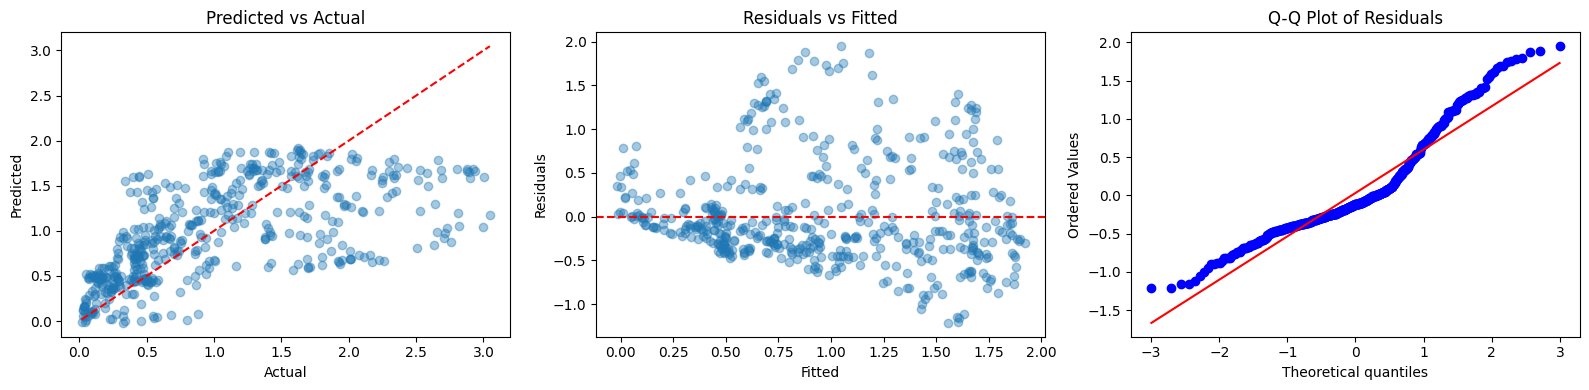

In [19]:
# Refit Linear Regression on the final 4-feature set (is_offshore_center dropped)
lr_final = LinearRegression()
lr_final.fit(X_train_f, y_train)

y_pred_test = lr_final.predict(X_test_f)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_test, y_pred_test, alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual')

axes[1].scatter(y_pred_test, residuals, alpha=0.4)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Fitted'); axes[1].set_ylabel('Residuals'); axes[1].set_title('Residuals vs Fitted')

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [20]:
# Check if residuals correlate with any single feature (hints at missing non-linearity)
for col in features_final:
    corr = np.corrcoef(X_test_f[col], residuals)[0, 1]
    print(f"Residuals vs {col}: r={corr:.3f}")

Residuals vs governance_index: r=-0.021
Residuals vs log_gdp_per_capita: r=0.072
Residuals vs internet_users: r=0.020
Residuals vs unemployment_rate: r=-0.248


## Residual Diagnostics

- Predicted vs Actual: model underpredicts at high business density values, consistent with 
  moderate R² (~0.50) — captures general trend but compresses the top of the range.
- Residuals vs Fitted: mild non-linear pattern detected, not pure random scatter.
- Q-Q plot: residuals have heavier tails than normal distribution (mild deviation).
- Root cause investigation: residuals correlate with `unemployment_rate` (r=-0.248) far more than 
  other features (governance_index -0.02, internet_users 0.02, log_gdp_per_capita 0.07) — 
  unemployment's relationship with business density is likely non-linear/threshold-based, not 
  fully captured by a single linear term.
- **Decision**: retain Linear Regression as final model (still best on cross-validated R² vs 
  alternatives tested), but document this as a known limitation and candidate for future work 
  (e.g., adding a squared or binned unemployment term).

In [21]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_f)
X_test_scaled = scaler_X.transform(X_test_f)

lr_std = LinearRegression()
lr_std.fit(X_train_scaled, y_train)

std_coef_df = pd.DataFrame({
    'feature': features_final,
    'standardized_coefficient': lr_std.coef_
}).sort_values('standardized_coefficient', key=abs, ascending=False)

print(std_coef_df)
print(f"\nTest R² (should match lr_final): {r2_score(y_test, lr_std.predict(X_test_scaled)):.4f}")

              feature  standardized_coefficient
0    governance_index                  0.398237
2      internet_users                  0.210944
3   unemployment_rate                  0.157445
1  log_gdp_per_capita                  0.007656

Test R² (should match lr_final): 0.3950


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = features_final
vif_data['VIF'] = [variance_inflation_factor(X_train_f.values, i) for i in range(len(features_final))]
print(vif_data)

              feature       VIF
0    governance_index  1.707993
1  log_gdp_per_capita  9.558560
2      internet_users  9.120934
3   unemployment_rate  2.653381


## Multicollinearity Check (VIF)

| Feature | VIF |
|---------|-----|
| governance_index | 1.71 |
| log_gdp_per_capita | 9.56 |
| internet_users | 9.12 |
| unemployment_rate | 2.65 |

`log_gdp_per_capita` and `internet_users` show meaningful multicollinearity (VIF ≈ 9, near the 
conventional threshold of 10) — both correlate with each other and with governance_index, since 
wealthier, better-governed countries also have higher internet penetration. This explains why 
GDP's standardized coefficient (0.008) is near-zero despite a strong raw correlation with the 
target (r=0.65): its explanatory power is being absorbed by governance_index and internet_users 
in the multivariate model. Governance_index itself remains the cleanest, most independent signal 
(VIF=1.71) — reinforcing it as the most trustworthy driver identified in this analysis.